Student 1: name: Moriel Tomchin, i.d.: 206970063, github: https://github.com/morielsh57/ML_intro_course

Student 2: Tal Rozman, i.d.: 211680178, github: https://github.com/TalRozman/ML_intro_course

Student 3: Emma Hrinevitzky, i.d.: 206385858 , github: https://github.com/emmahr1998/ML_intro_course

Exercise 3: Clustering

1. Function to create synthetic data - please do not change

In [1]:
import numpy as np
from sklearn.datasets import make_blobs, make_moons
import matplotlib.pyplot as plt


def create_data(the_noise, n1_samples, n2_samples, n3_samples, n4_samples):
  # 1
  X_1, y_1 = make_blobs(
    n_samples=n1_samples,
    centers=4,
    random_state=42)

  # 2
  X_2, y_2 = make_moons(
      n_samples=n2_samples,
      noise=the_noise,
      random_state=42
  )

  X_2[:, 0] += 10
  X_2[:, 1] += 10

  # 3
  rng = np.random.RandomState(42)
  angles = rng.rand(n3_samples) * 2 * np.pi
  r = 5.0 + rng.randn(n3_samples) * the_noise
  X_3 = np.column_stack((r * np.cos(angles), r * np.sin(angles)))
  X_3[:, 0] += 20


  # combine
  X = np.vstack((X_1, X_2, X_3))


  return X

2. Call create_data and visualize the data


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


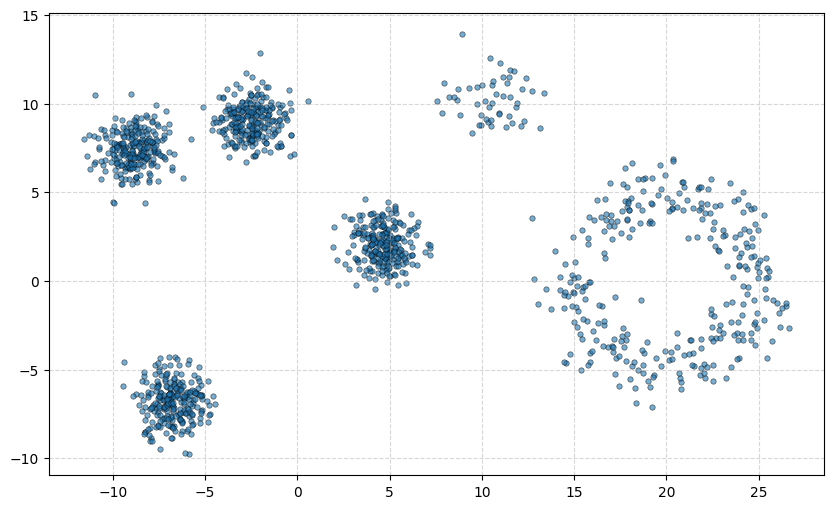

In [2]:
!pip -q install mlflow

X = create_data(1.0, 1000, 50, 300, 200)

# Data visuazliation is here:
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], s=15, alpha=0.6, edgecolors='k', linewidths=0.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

3. Train KMeans
- use library sklearn.cluster.KMeans
- training data: X
- explore and optimize KMeans options
- choose the number of clusters using the Silhouette Method    

In [3]:
import mlflow
import mlflow.sklearn
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

X_mean = np.mean(X, axis=0)
TSS = np.sum((X - X_mean) ** 2)

experiment_name = "KMeans_Optimization"
mlflow.set_experiment(experiment_name)

range_n_clusters = range(2, 21)
kmeans_results_list = []

print(f"Starting experiments in MLFlow: {experiment_name}")

for k in range_n_clusters:
    with mlflow.start_run(run_name=f"KMeans_k_{k}"):
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        kmeans.fit(X)
        cluster_labels = kmeans.labels_

        sil_score = silhouette_score(X, cluster_labels)
        wcss = kmeans.inertia_
        bcss = TSS - wcss
        variance_ratio = bcss / TSS

        mlflow.log_param("n_clusters", k)
        mlflow.log_metric("silhouette_score", sil_score)
        mlflow.log_metric("WCSS", wcss)
        mlflow.log_metric("BCSS", bcss)
        mlflow.log_metric("Explained_Variance", variance_ratio)

        mlflow.sklearn.log_model(kmeans, name="model")
        
        kmeans_results_list.append({
            "Experiment_ID": mlflow.active_run().info.run_id,
            "Run_Name": f"KMeans_k_{k}",
            "k (Clusters)": k,
            "Silhouette_Score": sil_score,
            "WCSS": wcss,
            "BCSS": bcss,
            "BCSS/TSS Ratio": variance_ratio
        })
        
        print(f"k={k}: Silhouette={sil_score:.4f} | WCSS={wcss:.2f} | BCSS={bcss:.2f} | variance_ratio={variance_ratio:.2f}")
kmeans_best_result = max(kmeans_results_list, key=lambda x: x['Silhouette_Score'])
kmeans_best_k = kmeans_best_result['k (Clusters)']


print("-" * 30)
print(f"OPTIMAL NUMBER OF CLUSTERS FOUND (by Silhouette): k = {kmeans_best_k}")

Starting experiments in MLFlow: KMeans_Optimization


k=2: Silhouette=0.5673 | WCSS=83212.63 | BCSS=127843.68 | variance_ratio=0.61


k=3: Silhouette=0.5858 | WCSS=47215.83 | BCSS=163840.49 | variance_ratio=0.78


k=4: Silhouette=0.6813 | WCSS=19465.56 | BCSS=191590.75 | variance_ratio=0.91


k=5: Silhouette=0.6976 | WCSS=14089.74 | BCSS=196966.57 | variance_ratio=0.93


...

k=16: Silhouette=0.4365 | WCSS=2210.78 | BCSS=208845.53 | variance_ratio=0.99


k=17: Silhouette=0.3681 | WCSS=2044.34 | BCSS=209011.97 | variance_ratio=0.99


k=18: Silhouette=0.3582 | WCSS=1966.47 | BCSS=209089.84 | variance_ratio=0.99


k=19: Silhouette=0.3682 | WCSS=1857.10 | BCSS=209199.21 | variance_ratio=0.99


k=20: Silhouette=0.3636 | WCSS=1759.04 | BCSS=209297.27 | variance_ratio=0.99
------------------------------
OPTIMAL NUMBER OF CLUSTERS FOUND (by Silhouette): k = 6


4. Train Agglomerative Clustering

- use library sklearn.cluster.AgglomerativeClustering
- training data: X
- explore and optimize AgglomerativeClustering options
- choose the number of clusters using any method you want  

In [4]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

experiment_name = "Agglomerative_Optimization"
mlflow.set_experiment(experiment_name)

range_n_clusters = range(2, 21)
Agglo_results_list = []

print(f"Starting experiments in MLFlow: {experiment_name}")

for k in range_n_clusters:
    with mlflow.start_run(run_name=f"Agglomerative_k_{k}"):
        model = AgglomerativeClustering(n_clusters=k, linkage='ward')
        cluster_labels = model.fit_predict(X)
        
        sil_score = silhouette_score(X, cluster_labels)
        wcss = 0
        for i in range(k):
            cluster_points = X[cluster_labels == i]
            centroid = cluster_points.mean(axis=0)
            wcss += np.sum((cluster_points - centroid) ** 2)
        bcss = TSS - wcss
        variance_ratio = bcss / TSS

        mlflow.log_param("n_clusters", k)
        mlflow.log_metric("silhouette_score", sil_score)
        mlflow.log_metric("WCSS", wcss)
        mlflow.log_metric("BCSS", bcss)
        mlflow.log_metric("Explained_Variance", variance_ratio)
        
        mlflow.sklearn.log_model(sk_model=model, name="model")
        
        Agglo_results_list.append({
            "Experiment_ID": mlflow.active_run().info.run_id,
            "Run_Name": f"Agglomerative_k_{k}",
            "k (Clusters)": k,
            "Silhouette_Score": sil_score,
            "WCSS": wcss,
            "BCSS": bcss,
            "BCSS/TSS Ratio": variance_ratio
        })
        
        print(f"k={k}: Silhouette={sil_score:.4f} | WCSS={wcss:.2f} | BCSS={bcss:.2f} | variance_ratio={variance_ratio:.2f}")

Agglo_best_result = max(Agglo_results_list, key=lambda x: x['Silhouette_Score'])
Agglo_best_k = Agglo_best_result['k (Clusters)']

print("-" * 30)
print(f"OPTIMAL NUMBER OF CLUSTERS FOUND (by Silhouette): k = {Agglo_best_k}")


Starting experiments in MLFlow: Agglomerative_Optimization


k=2: Silhouette=0.5698 | WCSS=86589.58 | BCSS=124466.73 | variance_ratio=0.59


k=3: Silhouette=0.5806 | WCSS=47923.96 | BCSS=163132.35 | variance_ratio=0.77


k=4: Silhouette=0.6813 | WCSS=19483.46 | BCSS=191572.85 | variance_ratio=0.91


k=5: Silhouette=0.6978 | WCSS=14107.64 | BCSS=196948.68 | variance_ratio=0.93


...

k=16: Silhouette=0.3444 | WCSS=2281.29 | BCSS=208775.02 | variance_ratio=0.99


k=17: Silhouette=0.3496 | WCSS=2169.72 | BCSS=208886.59 | variance_ratio=0.99


k=18: Silhouette=0.3462 | WCSS=2059.06 | BCSS=208997.25 | variance_ratio=0.99


k=19: Silhouette=0.3387 | WCSS=1970.63 | BCSS=209085.68 | variance_ratio=0.99


k=20: Silhouette=0.3341 | WCSS=1888.28 | BCSS=209168.03 | variance_ratio=0.99
------------------------------
OPTIMAL NUMBER OF CLUSTERS FOUND (by Silhouette): k = 6


5. Train DBSCAN
- use library sklearn.cluster.DBSCAN
- training data: X
- explore and optimize DBSCAN options


In [5]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import itertools

eps_values = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5]
min_samples_values = [3, 5, 10]

param_combinations = list(itertools.product(eps_values, min_samples_values))
db_results_list = []

print(f"Starting experiments in MLFlow: {experiment_name}")

for i, (eps, min_samples) in enumerate(param_combinations):
    run_name = f"DBSCAN_eps_{eps}_min_{min_samples}"
    
    with mlflow.start_run(run_name=run_name):
        model = DBSCAN(eps=eps, min_samples=min_samples)
        cluster_labels = model.fit_predict(X)
        
        unique_labels = set(cluster_labels)
        n_clusters_found = len(unique_labels) - (1 if -1 in cluster_labels else 0)
        n_noise = list(cluster_labels).count(-1)
        
        if n_clusters_found < 2:
            sil_score = -1.0
            print(f"Skipping metrics for eps={eps}, min={min_samples} (Clusters: {n_clusters_found})")
        else:
            sil_score = silhouette_score(X, cluster_labels)
            # wcss = 0
            for label in unique_labels:
                if label == -1: continue # Skip noise
                cluster_points = X[cluster_labels == label]
                centroid = cluster_points.mean(axis=0)


        mlflow.log_param("eps", eps)
        mlflow.log_param("min_samples", min_samples)
        mlflow.log_metric("clusters_found", n_clusters_found)
        mlflow.log_metric("noise_points", n_noise)
        mlflow.log_metric("silhouette_score", sil_score)
        
        mlflow.sklearn.log_model(sk_model=model, name="model")

        db_results_list.append({
            "Experiment_ID": mlflow.active_run().info.run_id,
            "Run_Name": f"DBSCAN_eps_{eps}_min_{min_samples}",
            "eps": eps,
            "min_samples": min_samples,
            "Clusters_Found": n_clusters_found,
            "Noise_Points": n_noise,
            "Silhouette_Score": sil_score,

        })
        
        if n_clusters_found >= 2:
            print(f"eps={eps}, min={min_samples}: Clusters={n_clusters_found} | Silhouette={sil_score:.4f} ")


valid_results = [r for r in db_results_list if r['Clusters_Found'] >= 2]

if valid_results:
    db_best_result = max(valid_results, key=lambda x: x['Silhouette_Score'])
    print("-" * 30)
    print(f"OPTIMAL CONFIGURATION FOUND:")
    print(f"eps = {db_best_result['eps']}, min_samples = {db_best_result['min_samples']}")
    print(f"Clusters: {db_best_result['Clusters_Found']} | Silhouette: {db_best_result['Silhouette_Score']:.4f}")
else:
    print("-" * 30)
    print("No valid clustering found (try adjusting eps/min_samples range).")

Starting experiments in MLFlow: Agglomerative_Optimization


eps=0.1, min=3: Clusters=59 | Silhouette=-0.4614 


eps=0.1, min=5: Clusters=10 | Silhouette=-0.6773 
Skipping metrics for eps=0.1, min=10 (Clusters: 0)


eps=0.3, min=3: Clusters=57 | Silhouette=-0.2064 


eps=0.3, min=5: Clusters=14 | Silhouette=-0.0555 


...

eps=0.7, min=10: Clusters=8 | Silhouette=0.4395 
eps=1.0, min=3: Clusters=6 | Silhouette=0.7135 


eps=1.0, min=5: Clusters=6 | Silhouette=0.7070 


eps=1.0, min=10: Clusters=9 | Silhouette=0.6190 


eps=1.5, min=3: Clusters=5 | Silhouette=0.6894 


eps=1.5, min=5: Clusters=5 | Silhouette=0.6894 
eps=1.5, min=10: Clusters=6 | Silhouette=0.7223 
------------------------------
OPTIMAL CONFIGURATION FOUND:
eps = 1.5, min_samples = 10
Clusters: 6 | Silhouette: 0.7223


6. Compare the results and choose the best method for the data


FINAL METHOD COMPARISON TABLE
       Method  Clusters  Silhouette        WCSS          BCSS
      K-Means         6    0.725118 9835.566667 201220.743838
Agglomerative         6    0.725690 9854.767341 201201.543164
       DBSCAN         6    0.722259         NaN           NaN
------------------------------------------------------------
THE WINNER IS: Agglomerative
(Silhouette Score: 0.7257)


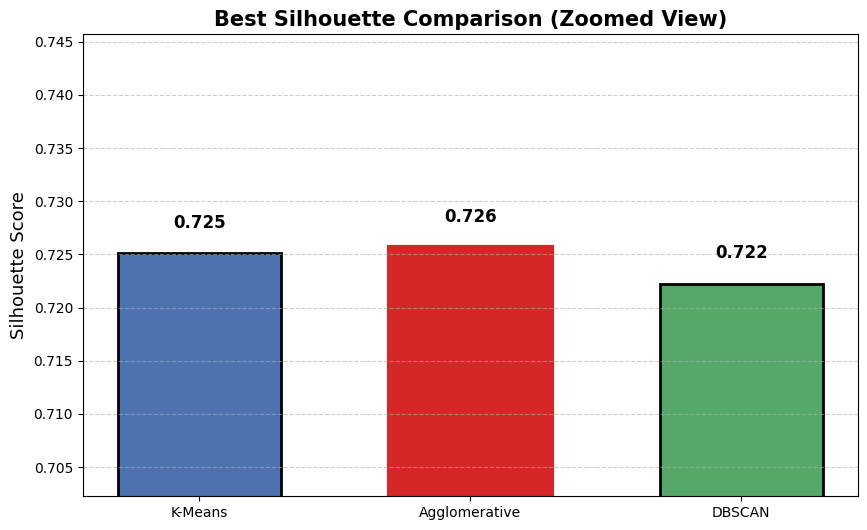

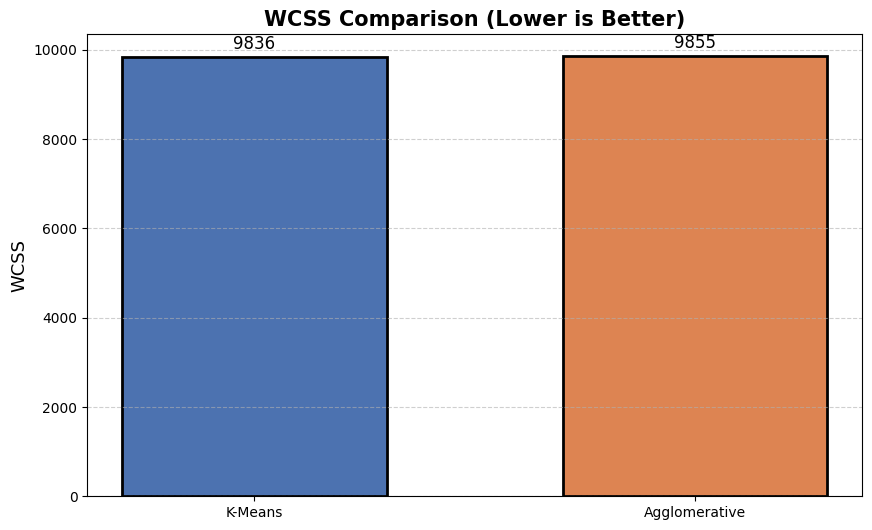

Final comparison table saved to Tal_Rozman_EX3.xlsx


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
 
comparison_data = [
    {
        'Method': 'K-Means',
        'Clusters': kmeans_best_result.get('k (Clusters)', kmeans_best_result.get('n_clusters')),
        'Silhouette': kmeans_best_result['Silhouette_Score'],
        'WCSS': kmeans_best_result['WCSS'],
        'BCSS': kmeans_best_result['BCSS']
    },
    {
        'Method': 'Agglomerative',
        'Clusters': Agglo_best_result['k (Clusters)'],
        'Silhouette': Agglo_best_result['Silhouette_Score'],
        'WCSS': Agglo_best_result['WCSS'],
        'BCSS': Agglo_best_result['BCSS']
    },
    {
        'Method': 'DBSCAN',
        'Clusters': db_best_result['Clusters_Found'],
        'Silhouette': db_best_result['Silhouette_Score'],
        'WCSS': np.nan,
        'BCSS': np.nan
    }
]
 
df_comparison = pd.DataFrame(comparison_data)
 

winner_idx = df_comparison['Silhouette'].idxmax()
winner_row = df_comparison.loc[winner_idx]
winner_method = winner_row['Method']
winner_score = winner_row['Silhouette']
 
print("=" * 60)
print("FINAL METHOD COMPARISON TABLE")
print("=" * 60)
print(df_comparison.to_string(index=False))
print("-" * 60)
print(f"THE WINNER IS: {winner_method}")
print(f"(Silhouette Score: {winner_score:.4f})")
print("=" * 60)
 
 
plt.figure(figsize=(10, 6))
colors = ['#4C72B0', '#DD8452', '#55A868']
bars = plt.bar(
    df_comparison['Method'],
    df_comparison['Silhouette'],
    color=colors,
    width=0.6,
    edgecolor='black',
    linewidth=2
)

bars[winner_idx].set_color('#D62728')
bars[winner_idx].set_linewidth(3)
 
y_vals = df_comparison['Silhouette']
y_min = min(y_vals)
y_max = max(y_vals)
 
plt.ylim(y_min - 0.02, y_max + 0.02)
 
plt.title('Best Silhouette Comparison (Zoomed View)', fontsize=15, fontweight='bold')
plt.ylabel('Silhouette Score', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.6)
 
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + 0.002,
        f'{height:.3f}',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )
 
plt.show()
 
 
plt.figure(figsize=(10, 6))
 
valid_wcss = df_comparison.dropna(subset=['WCSS'])
 
bars = plt.bar(
    valid_wcss['Method'],
    valid_wcss['WCSS'],
    color=['#4C72B0', '#DD8452'],
    width=0.6,
    edgecolor='black',
    linewidth=2
)
 
plt.title('WCSS Comparison (Lower is Better)', fontsize=15, fontweight='bold')
plt.ylabel('WCSS', fontsize=13)
plt.grid(axis='y', linestyle='--', alpha=0.6)
 
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.,
        height + height*0.01,
        f'{height:.0f}',
        ha='center',
        va='bottom',
        fontsize=12
    )
 
plt.show()
 


df_kmeans = pd.DataFrame(kmeans_results_list)
df_kmeans['Method'] = 'K-Means'

df_agglo = pd.DataFrame(Agglo_results_list)
df_agglo['Method'] = 'Agglomerative Clustering'

df_dbscan = pd.DataFrame(db_results_list)
df_dbscan['Method'] = 'DBSCAN'

final_df = pd.concat([df_kmeans, df_agglo, df_dbscan], ignore_index=True)


ordered_columns = [
    'Method',              # שם השיטה
    'Experiment_ID',       # מזהה ניסוי
    "Run_Name",

    'Silhouette_Score',
    'WCSS',
    'BCSS',

    'k (Clusters)',        # K-Means / Agglomerative
    'Clusters_Found',      # DBSCAN
    'Noise_Points',        # DBSCAN

    'eps',                 # DBSCAN
    'min_samples',         # DBSCAN
    'Architecture',        # Deep Learning
    'Latent_Dim',          # Deep Learning
    'Activation',          # Deep Learning
    'Optimizer',           # Deep Learning
    'linkage'              # Agglomerative
]


existing_cols = [col for col in ordered_columns if col in final_df.columns]
remaining_cols = [col for col in final_df.columns if col not in existing_cols]
final_df = final_df[existing_cols + remaining_cols]

output_filename = "Tal_Rozman_EX3.xlsx"
final_df.to_excel(output_filename, index=False)
files.download(output_filename)
print(f"Final comparison table saved to {output_filename}")